In [12]:
# ============================================================
# PROJECT : SMOTE-Enhanced Stacking Ensemble Intrusion Detection System
# Notebook : 05_SMOTE.ipynb
# Purpose  : Handle Class Imbalance using SMOTE
# Author   : Team
# ============================================================

print("="*70)
print("PHASE 5 : HANDLING CLASS IMBALANCE USING SMOTE")
print("="*70)

PHASE 5 : HANDLING CLASS IMBALANCE USING SMOTE


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from imblearn.over_sampling import SMOTE

import joblib
import os
import time

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [14]:
PROJECT_DIR = Path.cwd().parent

print("Project Directory:")
print(PROJECT_DIR)

Project Directory:
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System


In [15]:
DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"
MODEL_DIR = PROJECT_DIR / "models"
RESULT_DIR = PROJECT_DIR / "results"

DATASET_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset Folder :", DATASET_DIR)
print("Model Folder   :", MODEL_DIR)
print("Results Folder :", RESULT_DIR)

Dataset Folder : /srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset/cleaned
Model Folder   : /srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/models
Results Folder : /srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results


In [16]:
DATA_PATH = DATASET_DIR / "selected_features.csv"

df = pd.read_csv(DATA_PATH)

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

print("Shape :", df.shape)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset/cleaned/selected_features.csv'

In [20]:
from pathlib import Path

PROJECT_DIR = Path.cwd().parent

print("Searching for selected_features.csv...\n")

matches = list(PROJECT_DIR.rglob("selected_features.csv"))

if matches:
    print("Found file(s):")
    for m in matches:
        print(m)
else:
    print("selected_features.csv NOT FOUND")

Searching for selected_features.csv...

Found file(s):
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset/cleaned/selected_features.csv


In [18]:
for item in PROJECT_DIR.iterdir():
    print(item)

/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/requirements.txt
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/README.md
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/models
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dashboard
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/src
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/notebooks
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/.gitignore
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/api
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/run_pipeline.py


In [19]:
DATASET_DIR = PROJECT_DIR / "dataset"

print(DATASET_DIR)

if DATASET_DIR.exists():
    for path in DATASET_DIR.rglob("*"):
        print(path)
else:
    print("dataset folder does not exist.")

/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset/cleaned


In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd().parent

print(PROJECT_DIR)

/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System


In [3]:
cleaned_dir = PROJECT_DIR / "dataset" / "cleaned"

print("Cleaned Folder:", cleaned_dir)
print("\nFiles:")

for file in cleaned_dir.iterdir():
    print(file.name)

Cleaned Folder: /srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset/cleaned

Files:
selected_features.csv


In [4]:
DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"

DATA_PATH = DATASET_DIR / "selected_features.csv"

print("Dataset Path :", DATA_PATH)
print("Exists :", DATA_PATH.exists())

Dataset Path : /srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset/cleaned/selected_features.csv
Exists : True


In [9]:
df = pd.read_csv(DATA_PATH)

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

print("Shape :", df.shape)

df.head()

Dataset Loaded Successfully
Shape : (2522362, 31)


,Fwd IAT Std,Bwd IAT Min,Flow IAT Min,Bwd Packet Length Std,Bwd Packet Length Mean,Avg Bwd Segment Size,Idle Min,Bwd Packet Length Max,Idle Mean,Packet Length Std,...,PSH Flag Count,Active Mean,Fwd IAT Total,ACK Flag Count,Flow Duration,Bwd IAT Std,Subflow Fwd Bytes,Flow IAT Mean,Min Packet Length,Label
0,0.0,0,3,0.0,0.0,0.0,0,0,0.0,0.0,...,0,0.0,3,1,3,0.0,12,3.0,6,BENIGN
1,0.0,0,109,0.0,6.0,6.0,0,6,0.0,0.0,...,0,0.0,0,1,109,0.0,6,109.0,6,BENIGN
2,0.0,0,52,0.0,6.0,6.0,0,6,0.0,0.0,...,0,0.0,0,1,52,0.0,6,52.0,6,BENIGN
3,0.0,0,34,0.0,6.0,6.0,0,6,0.0,0.0,...,0,0.0,0,1,34,0.0,6,34.0,6,BENIGN
4,0.0,0,3,0.0,0.0,0.0,0,0,0.0,0.0,...,0,0.0,3,1,3,0.0,12,3.0,6,BENIGN


In [10]:

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

df.info()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 2522362 entries, 0 to 2522361
Data columns (total 31 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Fwd IAT Std             float64
 1   Bwd IAT Min             int64  
 2   Flow IAT Min            int64  
 3   Bwd Packet Length Std   float64
 4   Bwd Packet Length Mean  float64
 5   Avg Bwd Segment Size    float64
 6   Idle Min                int64  
 7   Bwd Packet Length Max   int64  
 8   Idle Mean               float64
 9   Packet Length Std       float64
 10  Idle Max                int64  
 11  Flow IAT Max            int64  
 12  Max Packet Length       int64  
 13  Fwd IAT Max             int64  
 14  Packet Length Variance  float64
 15  Average Packet Size     float64
 16  Packet Length Mean      float64
 17  Active Min              int64  
 18  FIN Flag Count          int64  
 19  Active Std              float64
 20  Flow IAT Std            float64
 21  PSH Flag Count        

In [11]:
print("=" * 70)
print("MISSING VALUE ANALYSIS")
print("=" * 70)

missing = df.isnull().sum()

print(missing[missing > 0])

print("\nTotal Missing Values :", missing.sum())

MISSING VALUE ANALYSIS
Series([], dtype: int64)

Total Missing Values : 0


In [12]:
print("=" * 70)
print("DUPLICATE RECORD CHECK")
print("=" * 70)

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

DUPLICATE RECORD CHECK
Duplicate Rows : 532441


In [13]:
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print("Shape :", df.shape)
print("Duplicate Rows :", df.duplicated().sum())
print("Missing Values :", df.isnull().sum().sum())
print("\nColumns:\n")
print(df.columns.tolist())


DATASET SUMMARY
Shape : (2522362, 31)
Duplicate Rows : 532441
Missing Values : 0

Columns:

['Fwd IAT Std', 'Bwd IAT Min', 'Flow IAT Min', 'Bwd Packet Length Std', 'Bwd Packet Length Mean', 'Avg Bwd Segment Size', 'Idle Min', 'Bwd Packet Length Max', 'Idle Mean', 'Packet Length Std', 'Idle Max', 'Flow IAT Max', 'Max Packet Length', 'Fwd IAT Max', 'Packet Length Variance', 'Average Packet Size', 'Packet Length Mean', 'Active Min', 'FIN Flag Count', 'Active Std', 'Flow IAT Std', 'PSH Flag Count', 'Active Mean', 'Fwd IAT Total', 'ACK Flag Count', 'Flow Duration', 'Bwd IAT Std', 'Subflow Fwd Bytes', 'Flow IAT Mean', 'Min Packet Length', 'Label']


In [14]:
print("=" * 70)
print("REMOVING DUPLICATE RECORDS")
print("=" * 70)

rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)

print("Rows Before :", rows_before)
print("Rows After  :", rows_after)
print("Duplicates Removed :", rows_before - rows_after)

REMOVING DUPLICATE RECORDS
Rows Before : 2522362
Rows After  : 1989921
Duplicates Removed : 532441


In [15]:
print("=" * 70)
print("VERIFY CLEAN DATASET")
print("=" * 70)

print("Shape :", df.shape)
print("Duplicate Rows :", df.duplicated().sum())
print("Missing Values :", df.isnull().sum().sum())

VERIFY CLEAN DATASET
Shape : (1989921, 31)
Duplicate Rows : 0
Missing Values : 0


In [18]:
# Path to save the cleaned dataset
CLEAN_DATA_PATH = DATASET_DIR / "selected_features_clean.csv"

# Save the dataframe
df.to_csv(CLEAN_DATA_PATH, index=False)

print("✅ Clean dataset saved successfully!")
print("Location:", CLEAN_DATA_PATH)

✅ Clean dataset saved successfully!
Location: /srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset/cleaned/selected_features_clean.csv


In [19]:
for file in DATASET_DIR.iterdir():
    print(file.name)

selected_features_clean.csv
selected_features.csv


In [21]:
DATA_PATH = DATASET_DIR / "selected_features_clean.csv"

df = pd.read_csv(DATA_PATH)

In [22]:
print("=" * 70)
print("SEPARATING FEATURES AND TARGET")
print("=" * 70)

TARGET_COLUMN = "Label"

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

SEPARATING FEATURES AND TARGET
Feature Matrix Shape : (1989921, 30)
Target Vector Shape  : (1989921,)


In [23]:
from sklearn.preprocessing import LabelEncoder

print("=" * 70)
print("ENCODING TARGET LABELS")
print("=" * 70)

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:")

for i, cls in enumerate(label_encoder.classes_):
    print(f"{i} --> {cls}")

ENCODING TARGET LABELS
Classes:
0 --> BENIGN
1 --> Bot
2 --> DDoS
3 --> DoS GoldenEye
4 --> DoS Hulk
5 --> DoS Slowhttptest
6 --> DoS slowloris
7 --> FTP-Patator
8 --> Heartbleed
9 --> Infiltration
10 --> PortScan
11 --> SSH-Patator
12 --> Web Attack � Brute Force
13 --> Web Attack � Sql Injection
14 --> Web Attack � XSS


In [24]:
from sklearn.model_selection import train_test_split

print("=" * 70)
print("TRAIN TEST SPLIT")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

TRAIN TEST SPLIT
Training Samples : (1591936, 30)
Testing Samples  : (397985, 30)


In [25]:
import pandas as pd

print("=" * 70)
print("TRAINING CLASS DISTRIBUTION (BEFORE SMOTE)")
print("=" * 70)

train_distribution = pd.Series(y_train).value_counts().sort_index()

distribution_df = pd.DataFrame({
    "Class": label_encoder.inverse_transform(train_distribution.index),
    "Count": train_distribution.values
})

print(distribution_df)

TRAINING CLASS DISTRIBUTION (BEFORE SMOTE)
                         Class    Count
0                       BENIGN  1323620
1                          Bot     1070
2                         DDoS   102413
3                DoS GoldenEye     8225
4                     DoS Hulk   137593
5             DoS Slowhttptest     4182
6                DoS slowloris     4308
7                  FTP-Patator     4745
8                   Heartbleed        9
9                 Infiltration       29
10                    PortScan     1540
11                 SSH-Patator     2522
12    Web Attack � Brute Force     1142
13  Web Attack � Sql Injection       16
14            Web Attack � XSS      522


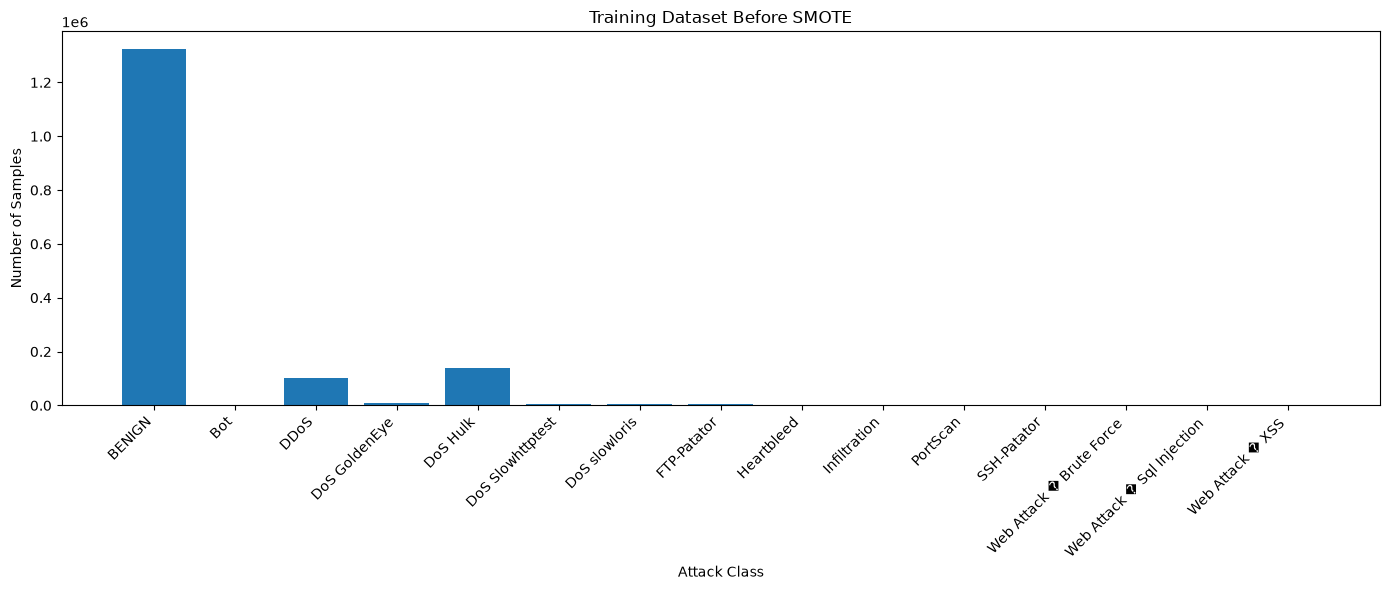

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.bar(
    distribution_df["Class"],
    distribution_df["Count"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Attack Class")
plt.ylabel("Number of Samples")
plt.title("Training Dataset Before SMOTE")

plt.tight_layout()

plt.show()

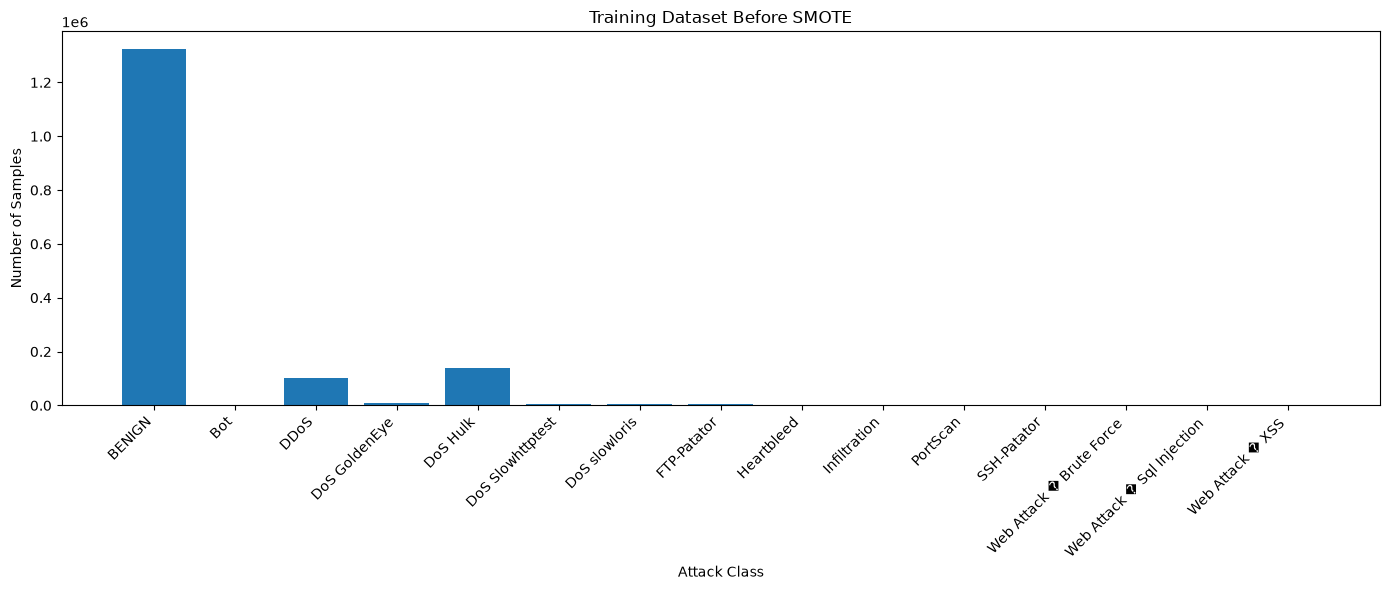

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.bar(
    distribution_df["Class"],
    distribution_df["Count"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Attack Class")
plt.ylabel("Number of Samples")
plt.title("Training Dataset Before SMOTE")

plt.tight_layout()

plt.show()

In [29]:
from imblearn.over_sampling import SMOTE

print("="*70)
print("APPLYING SMOTE")
print("="*70)

smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE Applied Successfully!")

APPLYING SMOTE
SMOTE Applied Successfully!


In [30]:
print("=" * 70)
print("DATASET SHAPES AFTER SMOTE")
print("=" * 70)

print("Original Training Shape")
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("\nBalanced Training Shape")
print("X_train_smote :", X_train_smote.shape)
print("y_train_smote :", y_train_smote.shape)

print("\nTesting Shape")
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

DATASET SHAPES AFTER SMOTE
Original Training Shape
X_train : (1591936, 30)
y_train : (1591936,)

Balanced Training Shape
X_train_smote : (19854300, 30)
y_train_smote : (19854300,)

Testing Shape
X_test : (397985, 30)
y_test : (397985,)


In [31]:
print("=" * 70)
print("CLASS DISTRIBUTION AFTER SMOTE")
print("=" * 70)

balanced_distribution = pd.Series(y_train_smote).value_counts().sort_index()

balanced_df = pd.DataFrame({
    "Class": label_encoder.inverse_transform(balanced_distribution.index),
    "Count": balanced_distribution.values
})

print(balanced_df)

CLASS DISTRIBUTION AFTER SMOTE
                         Class    Count
0                       BENIGN  1323620
1                          Bot  1323620
2                         DDoS  1323620
3                DoS GoldenEye  1323620
4                     DoS Hulk  1323620
5             DoS Slowhttptest  1323620
6                DoS slowloris  1323620
7                  FTP-Patator  1323620
8                   Heartbleed  1323620
9                 Infiltration  1323620
10                    PortScan  1323620
11                 SSH-Patator  1323620
12    Web Attack � Brute Force  1323620
13  Web Attack � Sql Injection  1323620
14            Web Attack � XSS  1323620


In [13]:
plt.figure(figsize=(14,6))

plt.bar(
    balanced_df["Class"],
    balanced_df["Count"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Attack Class")
plt.ylabel("Number of Samples")
plt.title("Training Dataset After SMOTE")

plt.tight_layout()

plt.show()

NameError: name 'balanced_df' is not defined

<Figure size 1400x600 with 0 Axes>

In [ ]:
print("=" * 70)
print("SAVING BALANCED DATASETS")
print("=" * 70)

X_train_smote.to_csv(DATASET_DIR / "X_train_smote.csv", index=False)

pd.DataFrame(y_train_smote, columns=["Label"]).to_csv(
    DATASET_DIR / "y_train_smote.csv",
    index=False
)

X_test.to_csv(DATASET_DIR / "X_test.csv", index=False)

pd.DataFrame(y_test, columns=["Label"]).to_csv(
    DATASET_DIR / "y_test.csv",
    index=False
)

print("Datasets Saved Successfully!")

In [46]:
print("X_train_smote" in locals())
print("y_train_smote" in locals())

True
True


In [2]:
import os

print(os.listdir(DATASET_DIR))

NameError: name 'DATASET_DIR' is not defined

In [3]:
print("PROJECT_DIR :", "PROJECT_DIR" in locals())
print("DATASET_DIR :", "DATASET_DIR" in locals())
print("df :", "df" in locals())
print("X_train :", "X_train" in locals())
print("y_train :", "y_train" in locals())
print("X_train_smote :", "X_train_smote" in locals())
print("y_train_smote :", "y_train_smote" in locals())

PROJECT_DIR : False
DATASET_DIR : False
df : False
X_train : False
y_train : False
X_train_smote : False
y_train_smote : False


In [ ]:
from start

In [4]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt

import joblib
import time
import os

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [5]:
PROJECT_DIR = Path.cwd().parent

DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"
MODEL_DIR = PROJECT_DIR / "models"

print(PROJECT_DIR)

/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System


In [6]:
DATA_PATH = DATASET_DIR / "selected_features_clean.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(1989921, 31)


,Fwd IAT Std,Bwd IAT Min,Flow IAT Min,Bwd Packet Length Std,Bwd Packet Length Mean,Avg Bwd Segment Size,Idle Min,Bwd Packet Length Max,Idle Mean,Packet Length Std,...,PSH Flag Count,Active Mean,Fwd IAT Total,ACK Flag Count,Flow Duration,Bwd IAT Std,Subflow Fwd Bytes,Flow IAT Mean,Min Packet Length,Label
0,0.0,0,3,0.0,0.0,0.0,0,0,0.0,0.0,...,0,0.0,3,1,3,0.0,12,3.0,6,BENIGN
1,0.0,0,109,0.0,6.0,6.0,0,6,0.0,0.0,...,0,0.0,0,1,109,0.0,6,109.0,6,BENIGN
2,0.0,0,52,0.0,6.0,6.0,0,6,0.0,0.0,...,0,0.0,0,1,52,0.0,6,52.0,6,BENIGN
3,0.0,0,34,0.0,6.0,6.0,0,6,0.0,0.0,...,0,0.0,0,1,34,0.0,6,34.0,6,BENIGN
4,0.0,0,1022,0.0,0.0,0.0,0,0,0.0,0.0,...,0,0.0,1022,1,1022,0.0,12,1022.0,6,BENIGN


In [7]:
TARGET = "Label"

X = df.drop(columns=[TARGET])

y = df[TARGET]

print(X.shape)
print(y.shape)

(1989921, 30)
(1989921,)


In [8]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

joblib.dump(
    encoder,
    MODEL_DIR/"label_encoder.pkl"
)

print("Encoder Saved")

Encoder Saved


In [10]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

In [11]:
X_train.to_parquet(DATASET_DIR/"X_train.parquet")

X_test.to_parquet(DATASET_DIR/"X_test.parquet")

pd.DataFrame({"Label":y_train}).to_parquet(
    DATASET_DIR/"y_train.parquet"
)

pd.DataFrame({"Label":y_test}).to_parquet(
    DATASET_DIR/"y_test.parquet"
)

print("Train/Test Saved")

Train/Test Saved


In [12]:
counts = pd.Series(y_train).value_counts().sort_index()

distribution = pd.DataFrame({
    "Class": encoder.inverse_transform(counts.index),
    "Count": counts.values
})

print(distribution)

                         Class    Count
0                       BENIGN  1323620
1                          Bot     1070
2                         DDoS   102413
3                DoS GoldenEye     8225
4                     DoS Hulk   137593
5             DoS Slowhttptest     4182
6                DoS slowloris     4308
7                  FTP-Patator     4745
8                   Heartbleed        9
9                 Infiltration       29
10                    PortScan     1540
11                 SSH-Patator     2522
12    Web Attack � Brute Force     1142
13  Web Attack � Sql Injection       16
14            Web Attack � XSS      522


In [14]:
print("=" * 70)
print("CREATING CUSTOM SMOTE STRATEGY")
print("=" * 70)

largest_attack = 137593

sampling_strategy = {}

for class_id, count in pd.Series(y_train).value_counts().sort_index().items():

    class_name = encoder.inverse_transform([class_id])[0]

    if class_name != "BENIGN":
        sampling_strategy[class_id] = largest_attack

print("Sampling Strategy\n")

for key, value in sampling_strategy.items():
    print(f"{encoder.inverse_transform([key])[0]:30s} -> {value}")

CREATING CUSTOM SMOTE STRATEGY
Sampling Strategy

Bot                            -> 137593
DDoS                           -> 137593
DoS GoldenEye                  -> 137593
DoS Hulk                       -> 137593
DoS Slowhttptest               -> 137593
DoS slowloris                  -> 137593
FTP-Patator                    -> 137593
Heartbleed                     -> 137593
Infiltration                   -> 137593
PortScan                       -> 137593
SSH-Patator                    -> 137593
Web Attack � Brute Force       -> 137593
Web Attack � Sql Injection     -> 137593
Web Attack � XSS               -> 137593


In [16]:
print("=" * 70)
print("APPLYING CUSTOM SMOTE")
print("=" * 70)

import time

start = time.time()

smote = SMOTE(
    sampling_strategy=sampling_strategy,
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

end = time.time()

print(f"\nSMOTE Completed in {(end-start)/60:.2f} minutes")

APPLYING CUSTOM SMOTE

SMOTE Completed in 0.09 minutes


In [17]:
print("=" * 70)
print("CLASS DISTRIBUTION AFTER CUSTOM SMOTE")
print("=" * 70)

balanced_distribution = pd.Series(y_train_smote).value_counts().sort_index()

balanced_df = pd.DataFrame({
    "Class": encoder.inverse_transform(balanced_distribution.index),
    "Count": balanced_distribution.values
})

print(balanced_df)

CLASS DISTRIBUTION AFTER CUSTOM SMOTE
                         Class    Count
0                       BENIGN  1323620
1                          Bot   137593
2                         DDoS   137593
3                DoS GoldenEye   137593
4                     DoS Hulk   137593
5             DoS Slowhttptest   137593
6                DoS slowloris   137593
7                  FTP-Patator   137593
8                   Heartbleed   137593
9                 Infiltration   137593
10                    PortScan   137593
11                 SSH-Patator   137593
12    Web Attack � Brute Force   137593
13  Web Attack � Sql Injection   137593
14            Web Attack � XSS   137593


In [18]:
print("=" * 70)
print("DATASET SHAPES")
print("=" * 70)

print("Original Training :", X_train.shape)
print("Balanced Training :", X_train_smote.shape)

print("Testing :", X_test.shape)

DATASET SHAPES
Original Training : (1591936, 30)
Balanced Training : (3249922, 30)
Testing : (397985, 30)


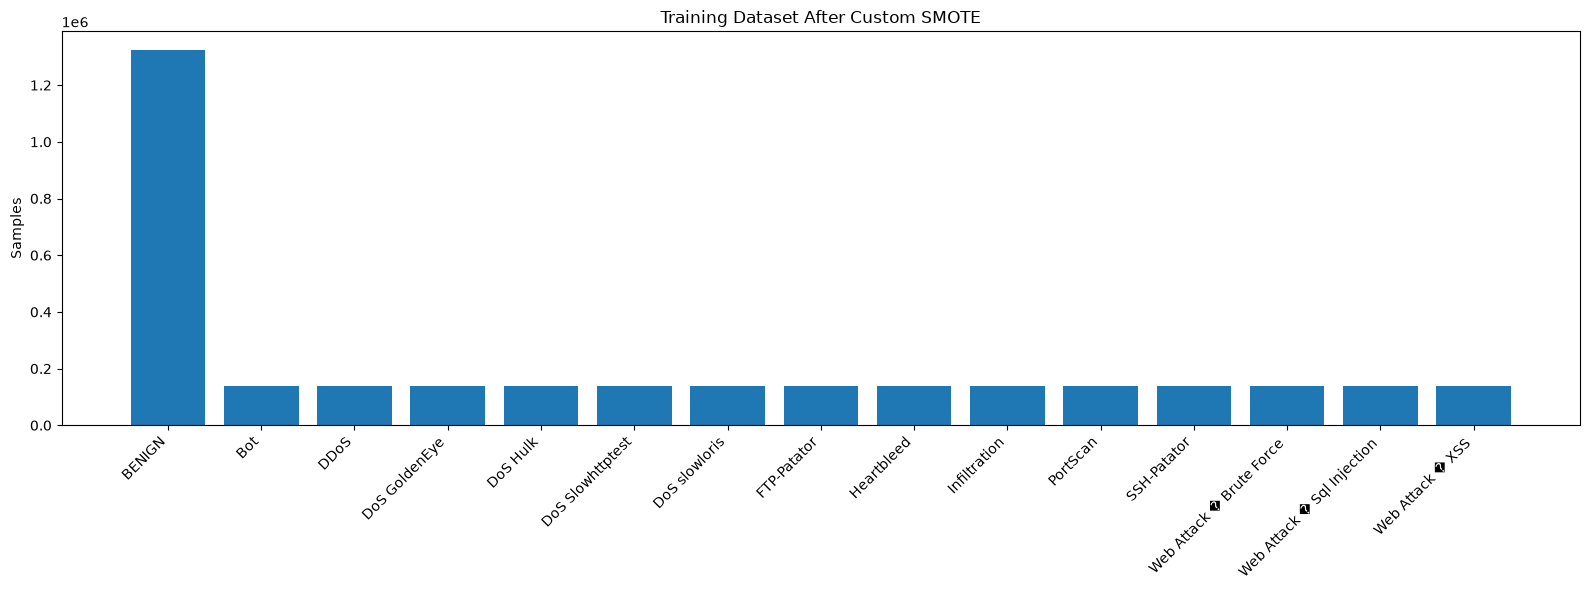

In [19]:
plt.figure(figsize=(16,6))

plt.bar(
    balanced_df["Class"],
    balanced_df["Count"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Samples")
plt.title("Training Dataset After Custom SMOTE")

plt.tight_layout()
plt.show()

In [20]:
print("=" * 70)
print("SAVING BALANCED DATASET")
print("=" * 70)

X_train_smote.to_parquet(
    DATASET_DIR / "X_train_smote.parquet",
    index=False
)

pd.DataFrame({
    "Label": y_train_smote
}).to_parquet(
    DATASET_DIR / "y_train_smote.parquet",
    index=False
)

print("Balanced Dataset Saved Successfully")

SAVING BALANCED DATASET
Balanced Dataset Saved Successfully


In [21]:
X_test.to_parquet(
    DATASET_DIR / "X_test.parquet",
    index=False
)

pd.DataFrame({
    "Label": y_test
}).to_parquet(
    DATASET_DIR / "y_test.parquet",
    index=False
)

print("Testing Dataset Saved Successfully")

Testing Dataset Saved Successfully


In [22]:
print("="*70)
print("Creating Smart Sampling Strategy")
print("="*70)

sampling_strategy = {

    # Medium attacks

    encoder.transform(["Bot"])[0]:100000,

    encoder.transform(["FTP-Patator"])[0]:100000,

    encoder.transform(["SSH-Patator"])[0]:100000,

    encoder.transform(["PortScan"])[0]:100000,

    encoder.transform(["DoS GoldenEye"])[0]:100000,

    encoder.transform(["DoS Slowhttptest"])[0]:100000,

    encoder.transform(["DoS slowloris"])[0]:100000,


    # Small attacks

    encoder.transform(["Heartbleed"])[0]:50000,

    encoder.transform(["Infiltration"])[0]:50000,

    encoder.transform(["Web Attack – Brute Force"])[0]:50000,

    encoder.transform(["Web Attack – Sql Injection"])[0]:50000,

    encoder.transform(["Web Attack – XSS"])[0]:50000

}

print(sampling_strategy)

Creating Smart Sampling Strategy


ValueError: y contains previously unseen labels: 'Web Attack – Brute Force'

In [24]:
print("=" * 70)
print("AVAILABLE LABELS")
print("=" * 70)

for label in encoder.classes_:
    print(repr(label))

AVAILABLE LABELS
'BENIGN'
'Bot'
'DDoS'
'DoS GoldenEye'
'DoS Hulk'
'DoS Slowhttptest'
'DoS slowloris'
'FTP-Patator'
'Heartbleed'
'Infiltration'
'PortScan'
'SSH-Patator'
'Web Attack � Brute Force'
'Web Attack � Sql Injection'
'Web Attack � XSS'


In [25]:
print("=" * 70)
print("CURRENT CLASS DISTRIBUTION")
print("=" * 70)

distribution = pd.DataFrame({
    "Label_ID": range(len(encoder.classes_)),
    "Class_Name": encoder.classes_,
    "Count": pd.Series(y_train).value_counts().sort_index().values
})

distribution

CURRENT CLASS DISTRIBUTION


,Label_ID,Class_Name,Count
0,0,BENIGN,1323620
1,1,Bot,1070
2,2,DDoS,102413
3,3,DoS GoldenEye,8225
4,4,DoS Hulk,137593
5,5,DoS Slowhttptest,4182
6,6,DoS slowloris,4308
7,7,FTP-Patator,4745
8,8,Heartbleed,9
9,9,Infiltration,29


In [26]:
sampling_strategy = {}

for idx, row in distribution.iterrows():

    label = row["Class_Name"]
    label_id = row["Label_ID"]
    count = row["Count"]

    # Skip BENIGN
    if label == "BENIGN":
        continue

    # Large attack classes → keep original
    if count >= 100000:
        continue

    # Medium attack classes
    elif count >= 1000:
        sampling_strategy[label_id] = 100000

    # Very small attack classes
    else:
        sampling_strategy[label_id] = 50000

print("=" * 70)
print("Sampling Strategy")
print("=" * 70)

for k, v in sampling_strategy.items():
    print(f"{encoder.classes_[k]:30} -> {v}")

Sampling Strategy
Bot                            -> 100000
DoS GoldenEye                  -> 100000
DoS Slowhttptest               -> 100000
DoS slowloris                  -> 100000
FTP-Patator                    -> 100000
Heartbleed                     -> 50000
Infiltration                   -> 50000
PortScan                       -> 100000
SSH-Patator                    -> 100000
Web Attack � Brute Force       -> 100000
Web Attack � Sql Injection     -> 50000
Web Attack � XSS               -> 50000


In [27]:
from imblearn.over_sampling import SMOTE
import time

print("=" * 70)
print("Applying Smart SMOTE")
print("=" * 70)

start = time.time()

smote = SMOTE(
    sampling_strategy=sampling_strategy,
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

end = time.time()

print(f"\nCompleted in {(end-start)/60:.2f} minutes")

Applying Smart SMOTE

Completed in 0.08 minutes


In [28]:
print("=" * 70)
print("CLASS DISTRIBUTION AFTER SMART SMOTE")
print("=" * 70)

balanced_distribution = pd.DataFrame({
    "Label_ID": range(len(encoder.classes_)),
    "Class_Name": encoder.classes_,
    "Count": pd.Series(y_train_smote).value_counts().sort_index().values
})

balanced_distribution

CLASS DISTRIBUTION AFTER SMART SMOTE


,Label_ID,Class_Name,Count
0,0,BENIGN,1323620
1,1,Bot,100000
2,2,DDoS,102413
3,3,DoS GoldenEye,100000
4,4,DoS Hulk,137593
5,5,DoS Slowhttptest,100000
6,6,DoS slowloris,100000
7,7,FTP-Patator,100000
8,8,Heartbleed,50000
9,9,Infiltration,50000


In [29]:
print("=" * 70)
print("DATASET SHAPE")
print("=" * 70)

print("Original Training :", X_train.shape)
print("Balanced Training :", X_train_smote.shape)
print("Testing :", X_test.shape)

DATASET SHAPE
Original Training : (1591936, 30)
Balanced Training : (2563626, 30)
Testing : (397985, 30)


In [30]:
X_train_smote.to_parquet(
    DATASET_DIR / "X_train_smote.parquet",
    index=False
)

pd.DataFrame({
    "Label": y_train_smote
}).to_parquet(
    DATASET_DIR / "y_train_smote.parquet",
    index=False
)

print("Balanced Dataset Saved Successfully")

Balanced Dataset Saved Successfully


In [31]:
before = pd.DataFrame({
    "Class": encoder.classes_,
    "Before": pd.Series(y_train).value_counts().sort_index().values
})

after = pd.DataFrame({
    "Class": encoder.classes_,
    "After": pd.Series(y_train_smote).value_counts().sort_index().values
})

comparison = before.merge(after, on="Class")

comparison

,Class,Before,After
0,BENIGN,1323620,1323620
1,Bot,1070,100000
2,DDoS,102413,102413
3,DoS GoldenEye,8225,100000
4,DoS Hulk,137593,137593
5,DoS Slowhttptest,4182,100000
6,DoS slowloris,4308,100000
7,FTP-Patator,4745,100000
8,Heartbleed,9,50000
9,Infiltration,29,50000


In [32]:
print(X_train_smote.shape)

(2563626, 30)


In [35]:
print("=" * 70)
print("SAVING FINAL BALANCED DATASET")
print("=" * 70)

X_train_smote.to_parquet(
    DATASET_DIR / "X_train_smote.parquet",
    index=False
)

pd.DataFrame({
    "Label": y_train_smote
}).to_parquet(
    DATASET_DIR / "y_train_smote.parquet",
    index=False
)

print("Balanced Dataset Saved Successfully")

SAVING FINAL BALANCED DATASET
Balanced Dataset Saved Successfully
